In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# ENVIRONMENT

env = gym.make("Blackjack-v1")

# PARAMETERS

GAMMA = 1.0
N_EPISODES = 500_000
EPSILON_START = 0.1
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.999995#0.99999   # slow decay

# Q TABLE + RETURNS

Q = defaultdict(lambda: np.zeros(env.action_space.n))
returns_sum = defaultdict(float)
returns_count = defaultdict(float)

# POLICY (ε-greedy)

def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(env.action_space.n)
    return np.argmax(Q[state])

# TRAINING LOOP (FIRST-VISIT MC CONTROL)

epsilon = EPSILON_START
returns_history = []

for episode in range(N_EPISODES):
    state, _ = env.reset()
    episode_data = []
    done = False

    # --- Generate Episode ---
    while not done:
        action = epsilon_greedy_policy(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        episode_data.append((state, action, reward))
        done = terminated or truncated
        state = next_state

    returns_history.append(reward)

    # --- First-Visit MC ---
    G = 0
    visited = set()

    for t in reversed(range(len(episode_data))):
        s, a, r = episode_data[t]
        G = GAMMA * G + r

        if (s, a) not in visited:
            visited.add((s, a))

            returns_sum[(s, a)] += G
            returns_count[(s, a)] += 1
            Q[s][a] = returns_sum[(s, a)] / returns_count[(s, a)]

    # --- ε decay ---
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if episode % 100000 == 0:
        print(f"Episode {episode}, epsilon={epsilon:.4f}")

env.close()
print("Training complete.")

Episode 0, epsilon=0.1000
Episode 100000, epsilon=0.0607
Episode 200000, epsilon=0.0368
Episode 300000, epsilon=0.0223
Episode 400000, epsilon=0.0135
Training complete.


In [3]:
def get_value_function(Q):
    V = {}
    for state, actions in Q.items():
        V[state] = np.max(actions)
    return V

V = get_value_function(Q)

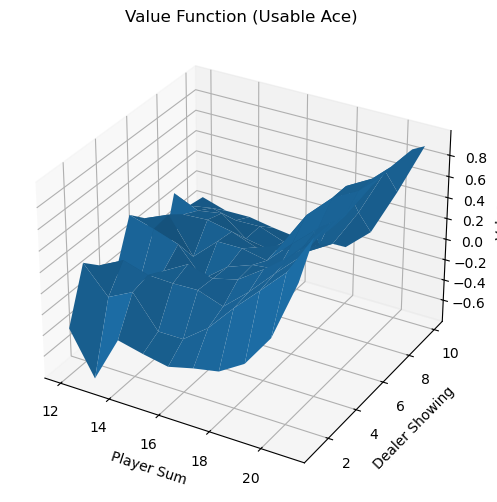

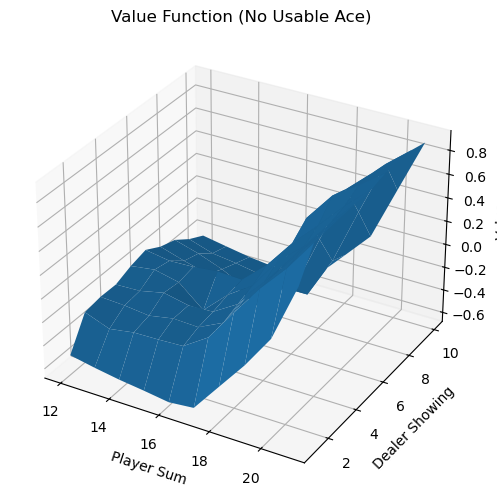

In [4]:
def plot_value_function(V, usable_ace=True):
    x_range = np.arange(12, 22)
    y_range = np.arange(1, 11)
    X, Y = np.meshgrid(x_range, y_range)

    Z = np.zeros_like(X, dtype=float)

    for i, player_sum in enumerate(x_range):
        for j, dealer_card in enumerate(y_range):
            state = (player_sum, dealer_card, usable_ace)
            Z[j, i] = V.get(state, 0)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z)
    ax.set_xlabel('Player Sum')
    ax.set_ylabel('Dealer Showing')
    ax.set_zlabel('Value')

    title = "Usable Ace" if usable_ace else "No Usable Ace"
    ax.set_title(f"Value Function ({title})")

    plt.show()

# Plot both cases
plot_value_function(V, usable_ace=True)
plot_value_function(V, usable_ace=False)

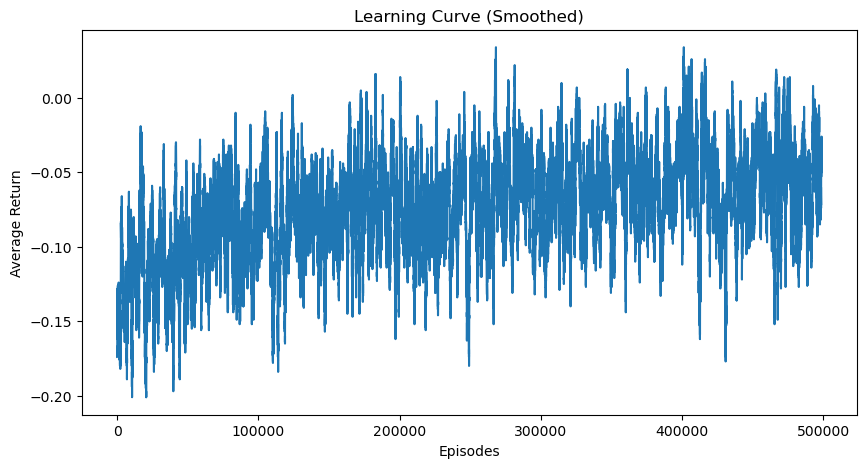

In [5]:
def plot_learning_curve(returns, window=1000):
    smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(10,5))
    plt.plot(smoothed)
    plt.xlabel("Episodes")
    plt.ylabel("Average Return")
    plt.title("Learning Curve (Smoothed)")
    plt.show()

plot_learning_curve(returns_history)

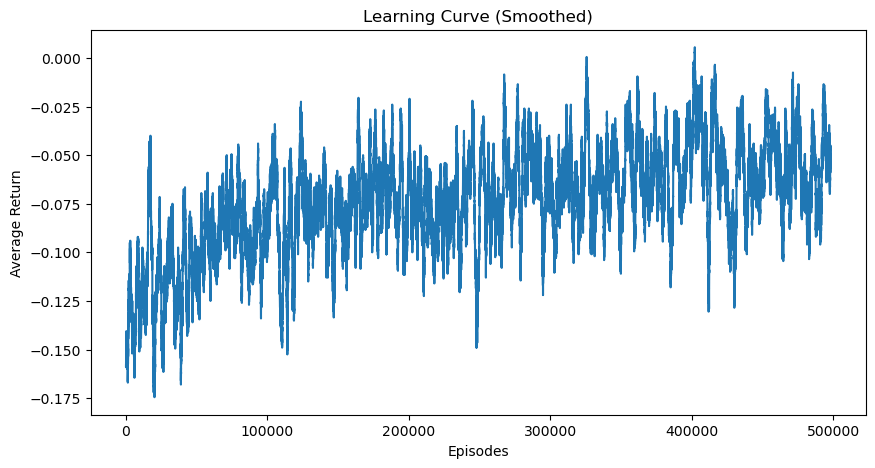

In [6]:
def plot_learning_curve(returns, window=2000):
    smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(10,5))
    plt.plot(smoothed)
    plt.xlabel("Episodes")
    plt.ylabel("Average Return")
    plt.title("Learning Curve (Smoothed)")
    plt.show()

plot_learning_curve(returns_history)

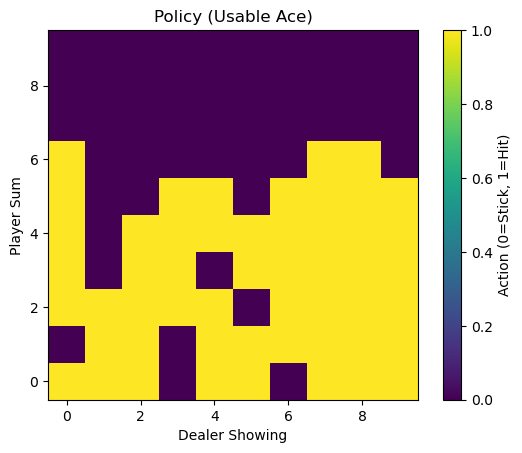

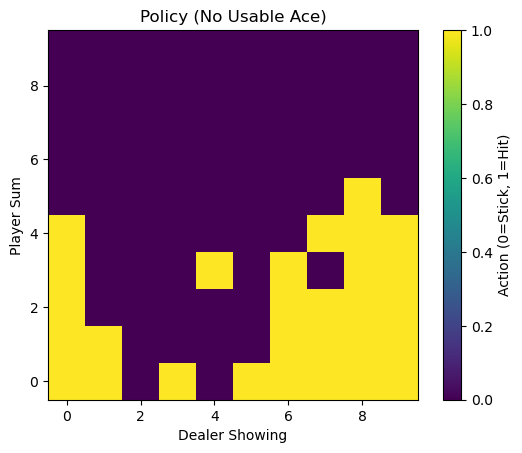

In [7]:
def plot_policy(Q, usable_ace=True):
    policy = np.zeros((10, 10))

    for player_sum in range(12, 22):
        for dealer_card in range(1, 11):
            state = (player_sum, dealer_card, usable_ace)
            action = np.argmax(Q[state])
            policy[player_sum-12, dealer_card-1] = action

    plt.imshow(policy, origin='lower')
    plt.colorbar(label="Action (0=Stick, 1=Hit)")
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    title = "Usable Ace" if usable_ace else "No Usable Ace"
    plt.title(f"Policy ({title})")
    plt.show()

plot_policy(Q, True)
plot_policy(Q, False)

Training with epsilon=0.01
Training with epsilon=0.1
Training with epsilon=0.2


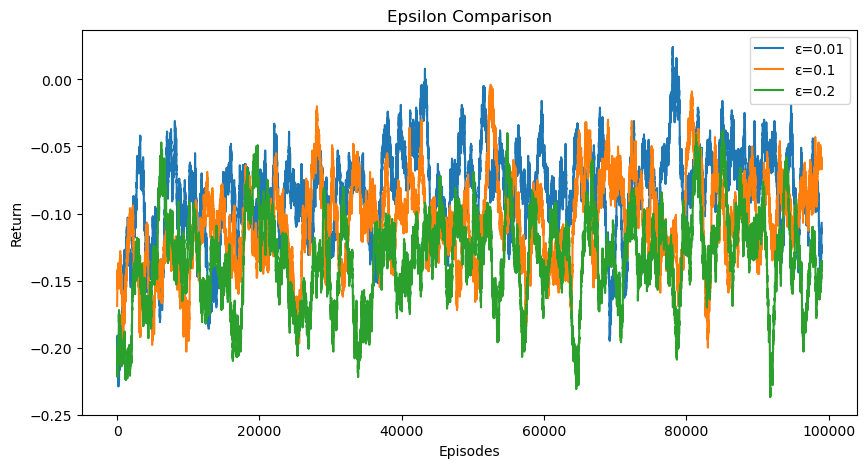

In [8]:
epsilons = [0.01, 0.1, 0.2]

results = {}

for eps in epsilons:
    print(f"Training with epsilon={eps}")
    
    Q_temp = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = []

    for episode in range(100000):
        state, _ = env.reset()
        episode_data = []
        done = False

        while not done:
            if np.random.rand() < eps:
                action = np.random.randint(env.action_space.n)
            else:
                action = np.argmax(Q_temp[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_data.append((state, action, reward))
            done = terminated or truncated
            state = next_state

        returns.append(reward)

        G = 0
        visited = set()

        for t in reversed(range(len(episode_data))):
            s, a, r = episode_data[t]
            G = G + r

            if (s, a) not in visited:
                visited.add((s, a))
                Q_temp[s][a] += 0.01 * (G - Q_temp[s][a])

    results[eps] = returns

# Plot comparison
plt.figure(figsize=(10,5))
for eps in epsilons:
    smoothed = np.convolve(results[eps], np.ones(1000)/1000, mode='valid')
    plt.plot(smoothed, label=f"ε={eps}")

plt.legend()
plt.title("Epsilon Comparison")
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.show()